<a href="https://colab.research.google.com/github/JMMV314/ANE2_procesamiento/blob/main/V01a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings, time
from contextlib import contextmanager
from numba import njit

warnings.filterwarnings("ignore")
try:
    from google.colab import files
except:
    files = None

# ----------------------------------------------------------------
# Timing helper
# ----------------------------------------------------------------
@contextmanager
def _timer(label, timers_dict):
    start = time.perf_counter()
    yield
    elapsed = time.perf_counter() - start
    timers_dict[label] = elapsed
    print(f"   {label}: {elapsed:.4f} s")

# ----------------------------------------------------------------
# Numba-accelerated peak detector (-3 dB BW)
# ----------------------------------------------------------------
@njit(fastmath=True)
def _find_peaks_numba(y, f, threshold):
    """Return list of (f_center, amplitude, bw) for every peak."""
    peaks = []
    N = len(y)
    i = 0
    while i < N:
        if y[i] > threshold:
            start = i
            while i < N and y[i] > threshold:
                i += 1
            end = i

            seg = y[start:end]
            idx = np.argmax(seg)
            peak_idx = start + idx
            f0 = f[peak_idx]
            a0 = seg[idx]

            half = a0 - 3.0
            # left side
            j = peak_idx
            while j > 0 and y[j] >= half:
                j -= 1
            f_low = f[max(0, j)]
            if j < peak_idx and j > 0:
                f_low = f[j] + (f[j+1] - f[j]) * (half - y[j]) / (y[j+1] - y[j])

            # right side
            j = peak_idx
            while j < N-1 and y[j] >= half:
                j += 1
            f_high = f[min(N-1, j)]
            if j > peak_idx and j < N:
                f_high = f[j-1] + (f[j] - f[j-1]) * (half - y[j-1]) / (y[j] - y[j-1])

            bw = max(f_high - f_low, 0.0)
            peaks.append((f0, a0, bw))
        else:
            i += 1
    return peaks

# ----------------------------------------------------------------
# Main Class
# ----------------------------------------------------------------
class DigitalSignalProcessing:
    def __init__(self,
                 file_path=None,
                 f_start=None,
                 f_stop=None,
                 gain_dBi=0.0,
                 bins=128,
                 delta_dB=0.5):
        self.file_path   = file_path
        self.f_start     = f_start
        self.f_stop      = f_stop
        self.gain_dBi    = gain_dBi
        self.bins        = bins
        self.delta_dB    = delta_dB
        self.df          = None
        self.noise_floor = None
        self.peaks_df    = None
        self.timers      = {}

        print(f"\n{'='*60}\n  STARTING HIGH-PERF DSP PIPELINE\n{'='*60}\n")

        # ------------------- Upload -------------------
        if self.file_path is None and files:
            with _timer("Upload CSV", self.timers):
                uploaded = files.upload()
                self.file_path = list(uploaded.keys())[0]
                print(f"   Uploaded: {self.file_path}")

        if not self.file_path:
            raise ValueError("No CSV file provided.")
        self.file_path = Path(self.file_path)

        # ------------------- Pipeline -------------------
        with _timer("Load CSV", self.timers):
            self._load_csv()

        with _timer("Convert to dBm/Hz", self.timers):
            self._convert_to_dBm_per_Hz()

        if f_start is not None and f_stop is not None:
            with _timer("Gain correction", self.timers):
                self._apply_gain_correction()

            with _timer("Noise floor", self.timers):
                self._estimate_noise_floor()

            with _timer("Peak detection", self.timers):
                self._detect_peaks_threshold()

            print(f"\nNoise floor: {self.noise_floor:.2f} dBm/Hz")

            with _timer("Plot: Original vs Corr", self.timers):
                self.plot_comparison()
            with _timer("Plot: PSD + NF", self.timers):
                self.plot_with_noise()
            with _timer("Plot: Peaks", self.timers):
                self.plot_detected_peaks()
            with _timer("Plot: PSD Histogram", self.timers):
                self.plot_psd_histogram()

        else:
            print("No frequency range → skipping analysis.")

        self._print_timing_summary()

    # ----------------------------------------------------------- #
    # 1) Load CSV
    # ----------------------------------------------------------- #
    def _load_csv(self):
        self.df = pd.read_csv(
            self.file_path,
            usecols=['Frecuencia (Hz)', 'PSD'],
            dtype={'Frecuencia (Hz)': np.float64, 'PSD': np.float64}
        )
        self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'}, inplace=True)
        self.df.drop_duplicates(subset='freq_Hz', inplace=True)
        self.df.sort_values('freq_Hz', inplace=True)
        self.df.reset_index(drop=True, inplace=True)
        print(f"   {len(self.df):,} points | "
              f"{self.df['freq_Hz'].min()/196:.2f}–{self.df['freq_Hz'].max()/1e6:.2f} MHz")

    # ----------------------------------------------------------- #
    # 2) Convert PSD to dBm/Hz
    # ----------------------------------------------------------- #
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz'].values
        if psd.mean() < 0:
            print("   Detected dB-scaled PSD → converting to linear")
            psd = 10 ** (psd / 10.0)
        psd = np.maximum(psd / 50.0, 1e-18)
        self.df['psd_dBmHz'] = 10 * np.log10(psd) + 30

    # ----------------------------------------------------------- #
    # 3) Apply gain correction
    # ----------------------------------------------------------- #
    def _apply_gain_correction(self):
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        self.df['psd_corr_dBmHz'] = self.df['psd_dBmHz'].copy()
        self.df.loc[mask, 'psd_corr_dBmHz'] -= self.gain_dBi
        print(f"   {self.gain_dBi:+.1f} dBi on "
              f"[{self.f_start/1e6:.2f},{self.f_stop/1e6:.2f}] MHz")

    # ----------------------------------------------------------- #
    # 4) Estimate noise floor
    # ----------------------------------------------------------- #
    def _estimate_noise_floor(self, max_iter=5, clip_pct=75, win_dB=6.0):
        x = self.df['psd_corr_dBmHz'].values
        for _ in range(max_iter):
            clip = np.percentile(x, clip_pct)
            x = x[x <= clip]
            if len(x) < 10: break
            counts, edges = np.histogram(x, bins=self.bins)
            i = np.argmax(counts)
            mode = (edges[i] + edges[i+1]) / 2.0
            mask = (x >= mode - win_dB/2) & (x <= mode + win_dB/2)
            if mask.sum() < 10: break
            x = x[mask]
        self.noise_floor = float(x.mean())
        print(f"   Noise floor = {self.noise_floor:.2f} dBm/Hz")

    # ----------------------------------------------------------- #
    # 5) Detect peaks + -3 dB BW
    # ----------------------------------------------------------- #
    def _detect_peaks_threshold(self):
        y = self.df['psd_corr_dBmHz'].values
        f = self.df['freq_Hz'].values
        thr = self.noise_floor + self.delta_dB
        raw = _find_peaks_numba(y, f, thr)
        if not raw:
            print(f"   No peaks > {thr:.2f} dBm/Hz")
            self.peaks_df = pd.DataFrame()
            return
        self.peaks_df = pd.DataFrame(raw,
            columns=['f_center_Hz','amplitude_dBmHz','bandwidth_Hz'])
        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz']/1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz']/1e3
        print(f"   {len(self.peaks_df)} peaks detected")

    # ----------------------------------------------------------- #
    # Plot: Original vs Corrected
    # ----------------------------------------------------------- #
    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns: return
        plt.figure(figsize=(11,5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original')
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], '--', label='Corrected')
        self._format_axis(plt.gca())
        plt.ylabel('PSD (dBm/Hz)')
        plt.title(title or "Original vs Gain-Corrected")
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    # ----------------------------------------------------------- #
    # Plot: PSD + Noise Floor
    # ----------------------------------------------------------- #
    def plot_with_noise(self, title=None):
        if self.noise_floor is None: return
        plt.figure(figsize=(11,5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], color='steelblue')
        plt.axhline(self.noise_floor, color='red', ls='--',
                    label=f'NF {self.noise_floor:.2f} dBm/Hz')
        self._format_axis(plt.gca())
        plt.ylabel('PSD (dBm/Hz)')
        plt.title(title or "PSD + Noise Floor")
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    # ----------------------------------------------------------- #
    # Plot: Detected Peaks
    # ----------------------------------------------------------- #
    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df)==0: return
        plt.figure(figsize=(11,5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='PSD')
        plt.scatter(self.peaks_df['f_center_Hz'],
                    self.peaks_df['amplitude_dBmHz'],
                    color='orange', zorder=5, label='Peaks')
        thr = self.noise_floor + self.delta_dB
        plt.axhline(thr, color='green', ls='--', alpha=.7,
                    label=f'Thr {thr:.2f} dBm/Hz')
        for _, r in self.peaks_df.iterrows():
            c, w = r['f_center_Hz'], r['bandwidth_Hz']/2
            # plt.axvspan(c-w, c+w, color='orange', alpha=.15)
        self._format_axis(plt.gca())
        plt.ylabel('PSD (dBm/Hz)')
        plt.title(title or "Peaks (-3 dB BW)")
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    # ----------------------------------------------------------- #
    # NEW: PSD Histogram
    # ----------------------------------------------------------- #
    def plot_psd_histogram(self, title=None, bins=None, show_stats=True):
        if 'psd_corr_dBmHz' not in self.df.columns:
            print("Gain correction not applied yet.")
            return
        if self.noise_floor is None:
            print("Noise floor not estimated.")
            return

        bins = bins or self.bins
        psd = self.df['psd_corr_dBmHz'].values

        plt.figure(figsize=(10, 6))
        counts, edges, _ = plt.hist(psd, bins=bins, color='steelblue', alpha=0.75, edgecolor='black', linewidth=0.5)

        plt.axvline(self.noise_floor, color='red', linestyle='--', linewidth=2,
                    label=f"Noise Floor: {self.noise_floor:.2f} dBm/Hz")
        plt.axvline(self.noise_floor + self.delta_dB, color='green', linestyle='--', linewidth=2,
                    label=f"Threshold: {self.noise_floor + self.delta_dB:.2f} dBm/Hz")

        if self.peaks_df is not None and len(self.peaks_df) > 0:
            peak_ampls = self.peaks_df['amplitude_dBmHz'].values
            plt.hist(peak_ampls, bins=bins, color='orange', alpha=0.7, edgecolor='darkorange',
                     label=f"Peaks (n={len(peak_ampls)})", histtype='step', linewidth=2)

        mean_val = psd.mean()
        std_val = psd.std()
        mode_idx = np.argmax(counts)
        mode_val = (edges[mode_idx] + edges[mode_idx + 1]) / 2

        if show_stats:
            stats_text = (
                f"Mean:  {mean_val:+6.2f} dBm/Hz\n"
                f"Std:   {std_val:6.2f} dB\n"
                f"Mode:  {mode_val:+6.2f} dBm/Hz\n"
                f"NF:    {self.noise_floor:+6.2f} dBm/Hz"
            )
            plt.text(0.97, 0.95, stats_text, transform=plt.gca().transAxes,
                     fontsize=10, verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

        plt.xlabel("Gain-Corrected PSD (dBm/Hz)")
        plt.ylabel("Count")
        plt.title(title or "PSD Histogram (Gain-Corrected)")
        plt.legend(loc="upper left")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ----------------------------------------------------------- #
    # Plot Helpers
    # ----------------------------------------------------------- #
    def _fmt_freq(self, x, _):
        if x >= 1e9: return f'{x/1e9:.2f}G'
        if x >= 1e6: return f'{x/1e6:.2f}M'
        if x >= 1e3: return f'{x/1e3:.1f}k'
        return f'{x:.0f}'
    def _format_axis(self, ax):
        ax.xaxis.set_major_formatter(plt.FuncFormatter(self._fmt_freq))
        ax.set_xlabel('Frequency')

    # ----------------------------------------------------------- #
    # Timing Summary
    # ----------------------------------------------------------- #
    def _print_timing_summary  (self):
        total = sum(self.timers.values())
        print(f"\n{'='*60}\n  TIMING SUMMARY\n{'='*60}")
        for step, t in self.timers.items():
            bar = "█" * int(50 * t/total) if total else ""
            print(f"  {step:28} {t:6.4f} s  [{bar}]")
        print(f"{'─'*60}\n  {'TOTAL':28} {total:6.4f} s\n{'='*60}\n")

    # ----------------------------------------------------------- #
    # Utilities
    # ----------------------------------------------------------- #
    def summary(self):
        print(f"\n{'='*50}\n DSP SUMMARY\n{'='*50}")
        print(f"File : {self.file_path.name}")
        print(f"Range: {self.df['freq_Hz'].min()/1e6:.3f}–{self.df['freq_Hz'].max()/1e6:.3f} MHz")
        print(f"Points: {len(self.df):,}")
        if self.noise_floor is not None:
            print(f"NF   : {self.noise_floor:.2f} dBm/Hz")
        print(f"Peaks: {len(self.peaks_df) if self.peaks_df is not None else 0}")
        print(f"{'='*50}\n")

    def export_peaks(self, path=None):
        if self.peaks_df is None or len(self.peaks_df)==0:
            print("No peaks → nothing to export")
            return
        p = path or f"peaks_{self.file_path.stem}.csv"
        self.peaks_df.to_csv(p, index=False)
        print(f"Peaks → {p}")


  STARTING HIGH-PERF DSP PIPELINE

   4,096 points | -51020.41–10.00 MHz
   Load CSV: 0.0109 s
   Detected dB-scaled PSD → converting to linear
   Convert to dBm/Hz: 0.0009 s
   +0.5 dBi on [-12.00,10.00] MHz
   Gain correction: 0.0023 s
   Noise floor = -66.63 dBm/Hz
   Noise floor: 0.0026 s
   55 peaks detected
   Peak detection: 0.7498 s

Noise floor: -66.63 dBm/Hz


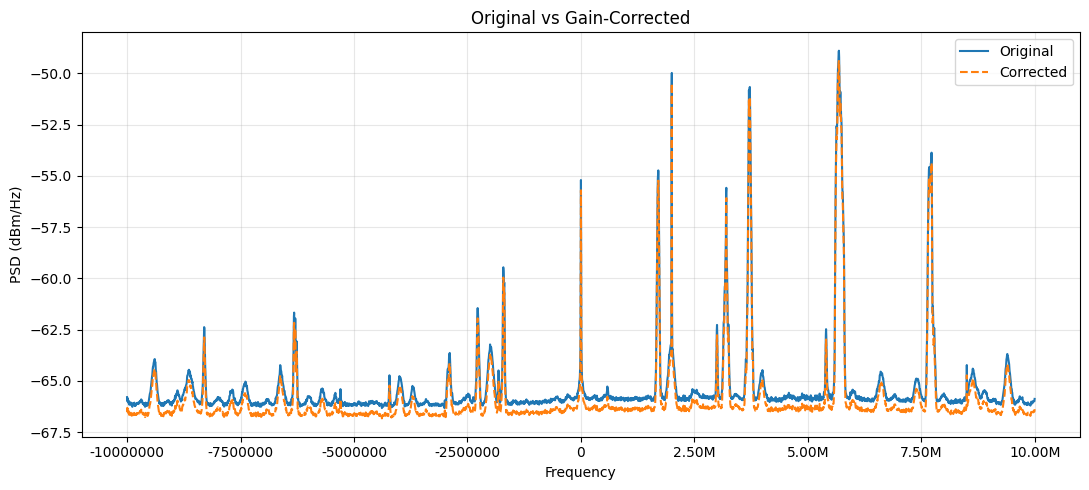

   Plot: Original vs Corr: 0.2511 s


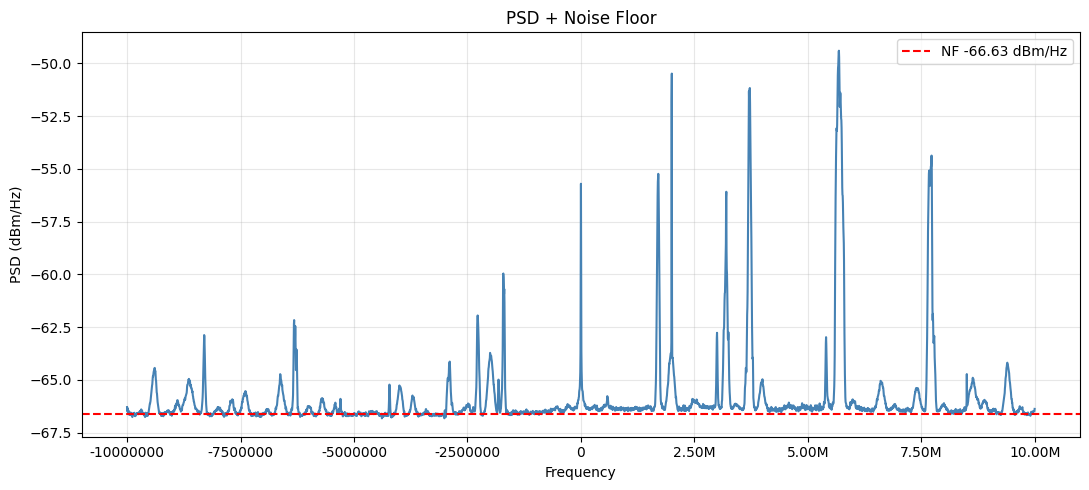

   Plot: PSD + NF: 0.2298 s


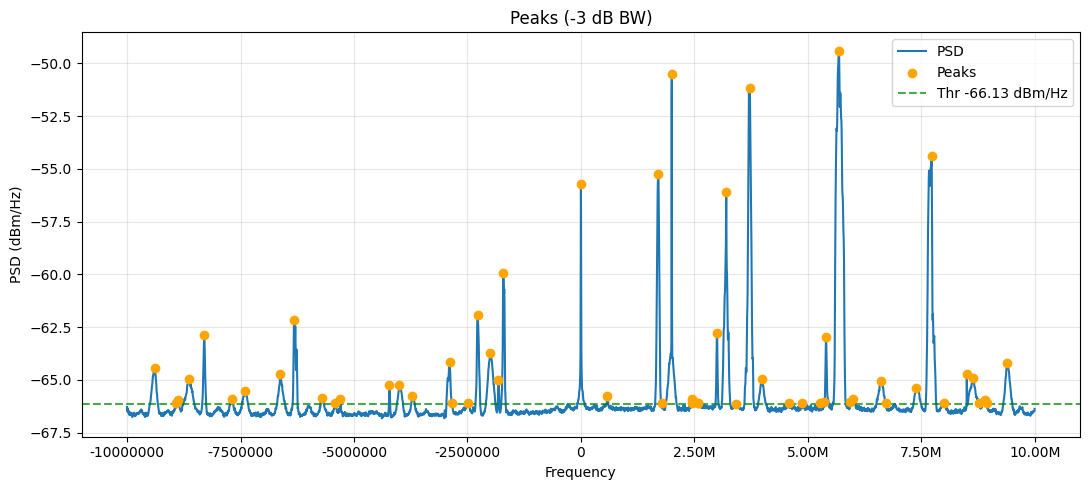

   Plot: Peaks: 0.2722 s


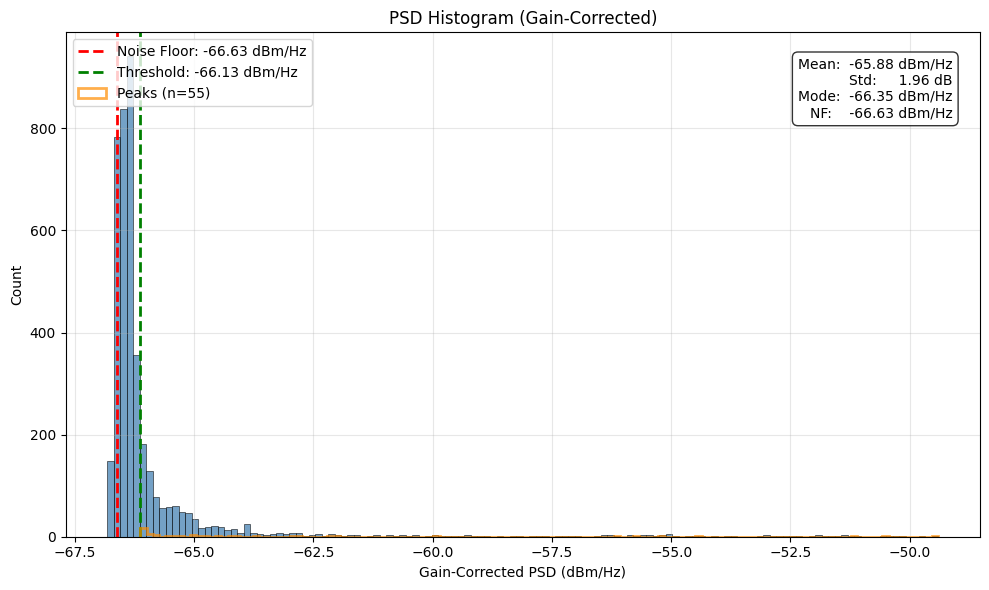

   Plot: PSD Histogram: 0.3995 s

  TIMING SUMMARY
  Load CSV                     0.0109 s  []
  Convert to dBm/Hz            0.0009 s  []
  Gain correction              0.0023 s  []
  Noise floor                  0.0026 s  []
  Peak detection               0.7498 s  [███████████████████]
  Plot: Original vs Corr       0.2511 s  [██████]
  Plot: PSD + NF               0.2298 s  [█████]
  Plot: Peaks                  0.2722 s  [███████]
  Plot: PSD Histogram          0.3995 s  [██████████]
────────────────────────────────────────────────────────────
  TOTAL                        1.9192 s



In [10]:
dsp = DigitalSignalProcessing(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)